In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


print("Hello, World!")
print(np.__version__)
print(cv2.__version__)

In [ ]:
# logic for the rest of the code goes here
'''
split_channels(image)

score_l2(img1, img2)
score_ncc(img1, img2)

align_single_scale(target, reference, search_range)

align_pyramid(target, reference)

colorize(image)

'''

In [ ]:
import numpy as np

def split_channels(image):
    """
    Splits an image into its individual color channels.

    Parameters:
        image (numpy.ndarray): The input image to be split.

    Returns:
        tuple: A tuple containing the individual color channels.
    """
    # Assuming the image is in RGB format
    if len(image.shape) == 3 and image.shape[2] == 3:
        return image[:, :, 0], image[:, :, 1], image[:, :, 2]
    else:
        raise ValueError("Input image must be a 3-channel RGB image.")

def score_l2(img1, img2):
    """
    Computes the L2 score (Euclidean distance) between two images.

    Parameters:
        img1 (numpy.ndarray): The first input image.
        img2 (numpy.ndarray): The second input image.

    Returns:
        float: The L2 score between the two images.
    """
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)

    if img1.shape != img2.shape:
        raise ValueError("Input images must have the same dimensions.")
    
    return np.sqrt(np.sum((img1 - img2) ** 2))

def score_ncc(img1, img2):
    """
    Computes the Normalized Cross-Correlation (NCC) score between two images.

    Parameters:
        img1 (numpy.ndarray): The first input image.
        img2 (numpy.ndarray): The second input image.

    Returns:
        float: The NCC score between the two images.
    """
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)

    if img1.shape != img2.shape:
        raise ValueError("Input images must have the same dimensions.")
    
    img1_mean = np.mean(img1)
    img2_mean = np.mean(img2)
    denom1 = np.linalg.norm(img1 - img1_mean)
    denom2 = np.linalg.norm(img2 - img2_mean)
    if denom1 < 1e-8 or denom2 < 1e-8:
        return 0.0  # Avoid division by zero
        
    img1_normalized = (img1 - img1_mean) / denom1
    img2_normalized = (img2 - img2_mean) / denom2

    return np.sum(img1_normalized * img2_normalized)

def align_single_scale(target, reference, search_range=15, select="ncc"):
    """
    Aligns the target image to the reference image using a single scale approach.

    Parameters:
        target (numpy.ndarray): The target image to be aligned.
        reference (numpy.ndarray): The reference image for alignment.
        search_range (int): The range of pixels to search for alignment.
        select (str): The metric to use for alignment ("ncc" or "l2").

    Returns:
        numpy.ndarray: The aligned target image.
    """
    # Placeholder for alignment logic
    
    border = search_range
    
    if select not in ["ncc", "l2"]:
        raise ValueError("Invalid selection for alignment metric. Choose 'ncc' or 'l2'.")

    best_dx_ncc, best_dy_ncc = 0, 0
    best_dx_l2, best_dy_l2 = 0, 0

    if select == "ncc":
        best_score_ncc = float('-inf')
        # Get best alignment using ncc score
        for i_x in range(-search_range, search_range + 1):
            for i_y in range(-search_range, search_range + 1):
                # Shift the target image
                shifted_target = np.roll(target, shift=(i_y, i_x), axis=(0, 1))
                # Compute the NCC score
                score = score_ncc(
                    shifted_target[border:-border, border:-border], 
                    reference[border:-border, border:-border]
                    )
                if score > best_score_ncc:
                    best_score_ncc = score
                    best_dx_ncc, best_dy_ncc = i_x, i_y
        aligned_ncc = np.roll(target, shift=(best_dy_ncc, best_dx_ncc), axis=(0, 1))
        return aligned_ncc, best_dx_ncc, best_dy_ncc, best_score_ncc

    else:
    # get best alignment using L2 score
        best_score_l2 = float('inf')
        for i_x in range(-search_range, search_range + 1):
            for i_y in range(-search_range, search_range + 1):
                # Shift the target image
                shifted_target = np.roll(target, shift=(i_y, i_x), axis=(0, 1))
                # Compute the L2 score
                score = score_l2(
                    shifted_target[border:-border, border:-border], 
                    reference[border:-border, border:-border]
                    )
                if score < best_score_l2:
                    best_score_l2 = score
                    best_dx_l2, best_dy_l2 = i_x, i_y

        aligned_l2 = np.roll(target, shift=(best_dy_l2, best_dx_l2), axis=(0, 1))
        return aligned_l2, best_dx_l2, best_dy_l2, best_score_l2
    
def align_pyramid(target, reference):
    """
    Aligns the target image to the reference image using a multi-scale pyramid approach.

    Parameters:
        target (numpy.ndarray): The target image to be aligned.
        reference (numpy.ndarray): The reference image for alignment.
    """
    pass

def colorize(image):
    """
    Colorizes a grayscale image.

    Parameters:
        image (numpy.ndarray): The input grayscale image to be colorized.

    Returns:
        numpy.ndarray: The colorized image.
    """

    
    # Placeholder for colorization logic
    pass


## Data Input ## 

In [ ]:
# input images data in sequence
import cv2
from pathlib import Path

data_dir = Path("../CS180_fa2026_proj1_data")

image_paths = [
    p for p in data_dir.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".tif", ".tiff"]
]

for img_path in image_paths:
    img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)

    if img is None:
        continue

    print("File:", img_path.name)
    print("Shape:", img.shape)
    print("Type:", img.dtype)



### Select an image to work with

In [ ]:
idx = 12
img_path = image_paths[idx]
img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
img = img.astype(np.float32)

# normalize every input image to [0, 1]
img_min = img.min()
img_max = img.max()

if img_max > img_min:
    img = (img - img_min) / (img_max - img_min)

print("shape:", img.shape)
print("dtype:", img.dtype)
print("min:", img.min())
print("max:", img.max())
print("mean:", img.mean())

print("File:", img_path.name)
print("Shape:", img.shape)

### Slice the images

In [ ]:
# slice the image into its color channels,
height = int(np.floor(img.shape[0] / 3.0))

# separate color channels
b = img[:height]
g = img[height: 2*height]
r = img[2*height: 3*height]

WIDTH = b.shape[1]
HEIGHT = b.shape[0]
CROP_X = int(WIDTH * 0.10)  # number of pixels to crop from each side
CROP_Y = int(HEIGHT * 0.10)  # number of pixels to crop from each side


print("Blue channel shape:", b.shape, "Green channel shape:", g.shape, "Red channel shape:", r.shape)

# crop the image to eliminate black borders
# and also divide by 255 to normalize the pixel values to [0, 1]
b_cropped = b[CROP_Y:-CROP_Y, CROP_X:-CROP_X]
g_cropped = g[CROP_Y:-CROP_Y, CROP_X:-CROP_X]
r_cropped = r[CROP_Y:-CROP_Y, CROP_X:-CROP_X]



### Show the sliced b\g\r images

In [ ]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(b_cropped, cmap='gray')
axes[0].set_title('Blue Channel')
axes[0].axis('off')

axes[1].imshow(g_cropped, cmap='gray')
axes[1].set_title('Green Channel')
axes[1].axis('off')

axes[2].imshow(r_cropped, cmap='gray')
axes[2].set_title('Red Channel')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print ("Blue channel shape:", b_cropped.shape, "Green channel shape:", g_cropped.shape, "Red channel shape:", r_cropped.shape)

## Single-scale Alignment 

### Use L2 Score

In [ ]:
# Set Blue channel as the reference channel
RANGE = 15
# 1. Align the Green channel to the Blue channel using L2 score
aligned_green_l2, dx_g_l2, dy_g_l2, score_g_l2 = align_single_scale(g_cropped, b_cropped, search_range=RANGE, select="l2")
print(f"Green channel aligned to Blue channel with L2 score: dx={dx_g_l2}, dy={dy_g_l2}, score={score_g_l2}")

# 2. Align the Red channel to the Blue channel using L2 score
aligned_red_l2, dx_r_l2, dy_r_l2, score_r_l2 = align_single_scale(r_cropped, b_cropped, search_range=RANGE, select="l2")
print(f"Red channel aligned to Blue channel with L2 score: dx={dx_r_l2}, dy={dy_r_l2}, score={score_r_l2}")



In [ ]:
# 3. Stack the aligned channels to form the final color image
color_img_l2 = np.dstack([
    aligned_red_l2,
    aligned_green_l2,
    b_cropped
])


In [ ]:
# 4. Show the final color image
plt.title(f"Using L2")
plt.imshow(color_img_l2)
plt.axis("off")
plt.show()

### Use NCC score ### 

In [ ]:
# Set Blue channel as the reference channel
RANGE = 15
# 1. Align the Green channel to the Blue channel using NCC score
aligned_green_ncc, dx_g_ncc, dy_g_ncc, score_g_ncc = align_single_scale(g_cropped, b_cropped, search_range=RANGE, select="ncc")
print(f"Green channel aligned to Blue channel with NCC score: dx={dx_g_ncc}, dy={dy_g_ncc}, score={score_g_ncc}")

# 2. Align the Red channel to the Blue channel using NCC score
aligned_red_ncc, dx_r_ncc, dy_r_ncc, score_r_ncc = align_single_scale(r_cropped, b_cropped, search_range=RANGE, select="ncc")
print(f"Red channel aligned to Blue channel with NCC score: dx={dx_r_ncc}, dy={dy_r_ncc}, score={score_r_ncc}")


In [ ]:
# 3. Stack the aligned channels to form the final color image
color_img_ncc = np.dstack([
    aligned_red_ncc,
    aligned_green_ncc,
    b_cropped
])

In [ ]:
# 4. Show the final color image
plt.title(f"Using NCC")
plt.imshow(color_img_ncc)
plt.axis("off")
plt.show()

### Combine and Save the L2 result && the NCC result


In [ ]:
import matplotlib.pyplot as plt

combined_img, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(color_img_l2)
axes[0].set_title('By L2')
axes[0].axis('off')

axes[1].imshow(color_img_ncc)
axes[1].set_title('By NCC')
axes[1].axis('off')

plt.tight_layout()

output_dir = Path("results")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / f"{img_path.stem}.jpg"

combined_img.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_path)

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


print("Hello, World!")
print(np.__version__)
print(cv2.__version__)

Hello, World!
2.2.5
4.10.0


In [2]:
# logic for the rest of the code goes here
'''
split_channels(image)

score_l2(img1, img2)
score_ncc(img1, img2)

align_single_scale(target, reference, search_range)

align_pyramid(target, reference)

colorize(image)

'''

'\nsplit_channels(image)\n\nscore_l2(img1, img2)\nscore_ncc(img1, img2)\n\nalign_single_scale(target, reference, search_range)\n\nalign_pyramid(target, reference)\n\ncolorize(image)\n\n'

In [3]:
import numpy as np

def split_channels(image):
    """
    Splits an image into its individual color channels.

    Parameters:
        image (numpy.ndarray): The input image to be split.

    Returns:
        tuple: A tuple containing the individual color channels.
    """
    # Assuming the image is in RGB format
    if len(image.shape) == 3 and image.shape[2] == 3:
        return image[:, :, 0], image[:, :, 1], image[:, :, 2]
    else:
        raise ValueError("Input image must be a 3-channel RGB image.")

def score_l2(img1, img2):
    """
    Computes the L2 score (Euclidean distance) between two images.

    Parameters:
        img1 (numpy.ndarray): The first input image.
        img2 (numpy.ndarray): The second input image.

    Returns:
        float: The L2 score between the two images.
    """
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)

    if img1.shape != img2.shape:
        raise ValueError("Input images must have the same dimensions.")
    
    return np.sqrt(np.sum((img1 - img2) ** 2))

def score_ncc(img1, img2):
    """
    Computes the Normalized Cross-Correlation (NCC) score between two images.

    Parameters:
        img1 (numpy.ndarray): The first input image.
        img2 (numpy.ndarray): The second input image.

    Returns:
        float: The NCC score between the two images.
    """
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)

    if img1.shape != img2.shape:
        raise ValueError("Input images must have the same dimensions.")
    
    img1_mean = np.mean(img1)
    img2_mean = np.mean(img2)
    denom1 = np.linalg.norm(img1 - img1_mean)
    denom2 = np.linalg.norm(img2 - img2_mean)
    if denom1 < 1e-8 or denom2 < 1e-8:
        return 0.0  # Avoid division by zero
        
    img1_normalized = (img1 - img1_mean) / denom1
    img2_normalized = (img2 - img2_mean) / denom2

    return np.sum(img1_normalized * img2_normalized)

def align_single_scale(target, reference, search_range=15, select="ncc"):
    """
    Aligns the target image to the reference image using a single scale approach.

    Parameters:
        target (numpy.ndarray): The target image to be aligned.
        reference (numpy.ndarray): The reference image for alignment.
        search_range (int): The range of pixels to search for alignment.
        select (str): The metric to use for alignment ("ncc" or "l2").

    Returns:
        numpy.ndarray: The aligned target image.
    """
    # Placeholder for alignment logic
    
    border = search_range
    
    if select not in ["ncc", "l2"]:
        raise ValueError("Invalid selection for alignment metric. Choose 'ncc' or 'l2'.")

    best_dx_ncc, best_dy_ncc = 0, 0
    best_dx_l2, best_dy_l2 = 0, 0

    if select == "ncc":
        best_score_ncc = float('-inf')
        # Get best alignment using ncc score
        for i_x in range(-search_range, search_range + 1):
            for i_y in range(-search_range, search_range + 1):
                # Shift the target image
                shifted_target = np.roll(target, shift=(i_y, i_x), axis=(0, 1))
                # Compute the NCC score
                score = score_ncc(
                    shifted_target[border:-border, border:-border], 
                    reference[border:-border, border:-border]
                    )
                if score > best_score_ncc:
                    best_score_ncc = score
                    best_dx_ncc, best_dy_ncc = i_x, i_y
        aligned_ncc = np.roll(target, shift=(best_dy_ncc, best_dx_ncc), axis=(0, 1))
        return aligned_ncc, best_dx_ncc, best_dy_ncc, best_score_ncc

    else:
    # get best alignment using L2 score
        best_score_l2 = float('inf')
        for i_x in range(-search_range, search_range + 1):
            for i_y in range(-search_range, search_range + 1):
                # Shift the target image
                shifted_target = np.roll(target, shift=(i_y, i_x), axis=(0, 1))
                # Compute the L2 score
                score = score_l2(
                    shifted_target[border:-border, border:-border], 
                    reference[border:-border, border:-border]
                    )
                if score < best_score_l2:
                    best_score_l2 = score
                    best_dx_l2, best_dy_l2 = i_x, i_y

        aligned_l2 = np.roll(target, shift=(best_dy_l2, best_dx_l2), axis=(0, 1))
        return aligned_l2, best_dx_l2, best_dy_l2, best_score_l2
    
def align_pyramid(target, reference):
    """
    Aligns the target image to the reference image using a multi-scale pyramid approach.

    Parameters:
        target (numpy.ndarray): The target image to be aligned.
        reference (numpy.ndarray): The reference image for alignment.
    """
    pass

def colorize(image):
    """
    Colorizes a grayscale image.

    Parameters:
        image (numpy.ndarray): The input grayscale image to be colorized.

    Returns:
        numpy.ndarray: The colorized image.
    """

    
    # Placeholder for colorization logic
    pass


## Data Input ## 

In [4]:
# input images data in sequence
import cv2
from pathlib import Path

data_dir = Path("../CS180_fa2026_proj1_data")

image_paths = [
    p for p in data_dir.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".tif", ".tiff"]
]

for img_path in image_paths:
    img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)

    if img is None:
        continue

    print("File:", img_path.name)
    print("Shape:", img.shape)
    print("Type:", img.dtype)



File: cathedral.jpg
Shape: (1024, 390)
Type: uint8
File: church.tif
Shape: (9607, 3634)
Type: uint16
File: emir.tif
Shape: (9627, 3702)
Type: uint16
File: harvesters.tif
Shape: (9656, 3683)
Type: uint16
File: icon.tif
Shape: (9732, 3741)
Type: uint16
File: ilemselga.tif
Shape: (9812, 3800)
Type: uint16
File: melons.tif
Shape: (9724, 3770)
Type: uint16
File: monastery.jpg
Shape: (1024, 391)
Type: uint8
File: religous_painting.tif
Shape: (9579, 3742)
Type: uint16
File: self_portrait.tif
Shape: (9754, 3810)
Type: uint16
File: siren.tif
Shape: (9752, 3817)
Type: uint16
File: three_generations.tif
Shape: (9629, 3714)
Type: uint16
File: tobolsk.jpg
Shape: (1024, 396)
Type: uint8
File: wharf.tif
Shape: (9734, 3761)
Type: uint16


### Select an image to work with

In [40]:
idx = 12
img_path = image_paths[idx]
img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
img = img.astype(np.float32)

# normalize every input image to [0, 1]
img_min = img.min()
img_max = img.max()

if img_max > img_min:
    img = (img - img_min) / (img_max - img_min)

print("shape:", img.shape)
print("dtype:", img.dtype)
print("min:", img.min())
print("max:", img.max())
print("mean:", img.mean())

print("File:", img_path.name)
print("Shape:", img.shape)

shape: (1024, 396)
dtype: float32
min: 0.0
max: 1.0
mean: 0.63136387
File: tobolsk.jpg
Shape: (1024, 396)


### Slice the images

In [41]:
# slice the image into its color channels,
height = int(np.floor(img.shape[0] / 3.0))

# separate color channels
b = img[:height]
g = img[height: 2*height]
r = img[2*height: 3*height]

WIDTH = b.shape[1]
HEIGHT = b.shape[0]
CROP_X = int(WIDTH * 0.10)  # number of pixels to crop from each side
CROP_Y = int(HEIGHT * 0.10)  # number of pixels to crop from each side


print("Blue channel shape:", b.shape, "Green channel shape:", g.shape, "Red channel shape:", r.shape)

# crop the image to eliminate black borders
# and also divide by 255 to normalize the pixel values to [0, 1]
b_cropped = b[CROP_Y:-CROP_Y, CROP_X:-CROP_X]
g_cropped = g[CROP_Y:-CROP_Y, CROP_X:-CROP_X]
r_cropped = r[CROP_Y:-CROP_Y, CROP_X:-CROP_X]



Blue channel shape: (341, 396) Green channel shape: (341, 396) Red channel shape: (341, 396)


### Show the sliced b\g\r images

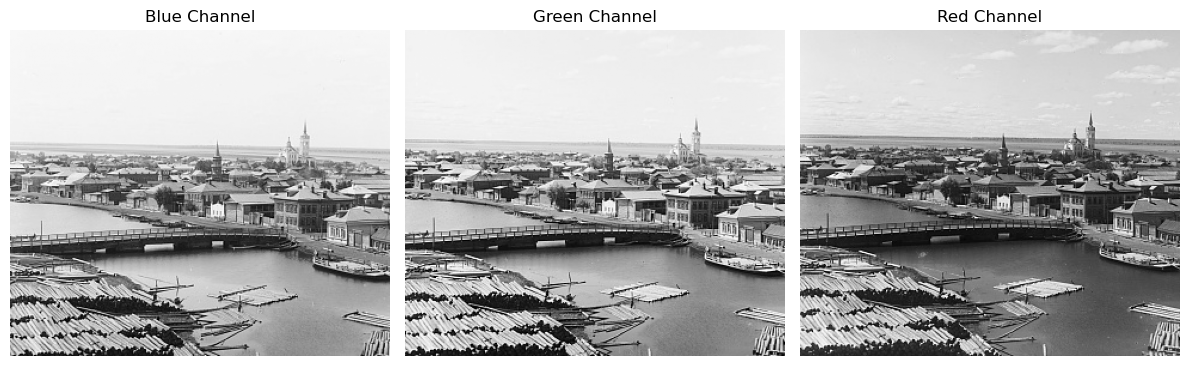

Blue channel shape: (273, 318) Green channel shape: (273, 318) Red channel shape: (273, 318)


In [42]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(b_cropped, cmap='gray')
axes[0].set_title('Blue Channel')
axes[0].axis('off')

axes[1].imshow(g_cropped, cmap='gray')
axes[1].set_title('Green Channel')
axes[1].axis('off')

axes[2].imshow(r_cropped, cmap='gray')
axes[2].set_title('Red Channel')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print ("Blue channel shape:", b_cropped.shape, "Green channel shape:", g_cropped.shape, "Red channel shape:", r_cropped.shape)

## Single-scale Alignment 

### Use L2 Score

In [43]:
# Set Blue channel as the reference channel
RANGE = 15
# 1. Align the Green channel to the Blue channel using L2 score
aligned_green_l2, dx_g_l2, dy_g_l2, score_g_l2 = align_single_scale(g_cropped, b_cropped, search_range=RANGE, select="l2")
print(f"Green channel aligned to Blue channel with L2 score: dx={dx_g_l2}, dy={dy_g_l2}, score={score_g_l2}")

# 2. Align the Red channel to the Blue channel using L2 score
aligned_red_l2, dx_r_l2, dy_r_l2, score_r_l2 = align_single_scale(r_cropped, b_cropped, search_range=RANGE, select="l2")
print(f"Red channel aligned to Blue channel with L2 score: dx={dx_r_l2}, dy={dy_r_l2}, score={score_r_l2}")



Green channel aligned to Blue channel with L2 score: dx=3, dy=3, score=27.864248275756836
Red channel aligned to Blue channel with L2 score: dx=3, dy=6, score=53.10014343261719


In [44]:
# 3. Stack the aligned channels to form the final color image
color_img_l2 = np.dstack([
    aligned_red_l2,
    aligned_green_l2,
    b_cropped
])


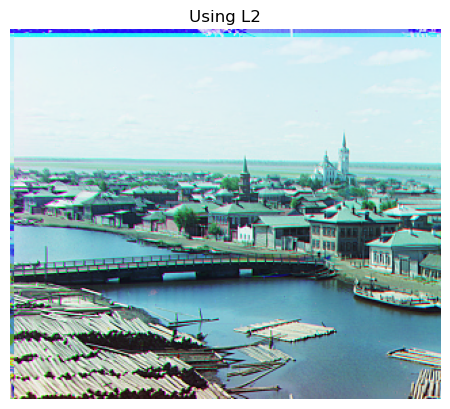

In [45]:
# 4. Show the final color image
plt.title(f"Using L2")
plt.imshow(color_img_l2)
plt.axis("off")
plt.show()

### Use NCC score ### 

In [46]:
# Set Blue channel as the reference channel
RANGE = 15
# 1. Align the Green channel to the Blue channel using NCC score
aligned_green_ncc, dx_g_ncc, dy_g_ncc, score_g_ncc = align_single_scale(g_cropped, b_cropped, search_range=RANGE, select="ncc")
print(f"Green channel aligned to Blue channel with NCC score: dx={dx_g_ncc}, dy={dy_g_ncc}, score={score_g_ncc}")

# 2. Align the Red channel to the Blue channel using NCC score
aligned_red_ncc, dx_r_ncc, dy_r_ncc, score_r_ncc = align_single_scale(r_cropped, b_cropped, search_range=RANGE, select="ncc")
print(f"Red channel aligned to Blue channel with NCC score: dx={dx_r_ncc}, dy={dy_r_ncc}, score={score_r_ncc}")


Green channel aligned to Blue channel with NCC score: dx=3, dy=3, score=0.9281731843948364
Red channel aligned to Blue channel with NCC score: dx=3, dy=6, score=0.8586486577987671


In [47]:
# 3. Stack the aligned channels to form the final color image
color_img_ncc = np.dstack([
    aligned_red_ncc,
    aligned_green_ncc,
    b_cropped
])

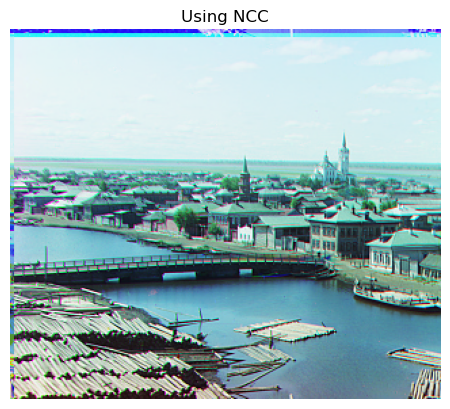

In [48]:
# 4. Show the final color image
plt.title(f"Using NCC")
plt.imshow(color_img_ncc)
plt.axis("off")
plt.show()

### Combine and Save the L2 result && the NCC result


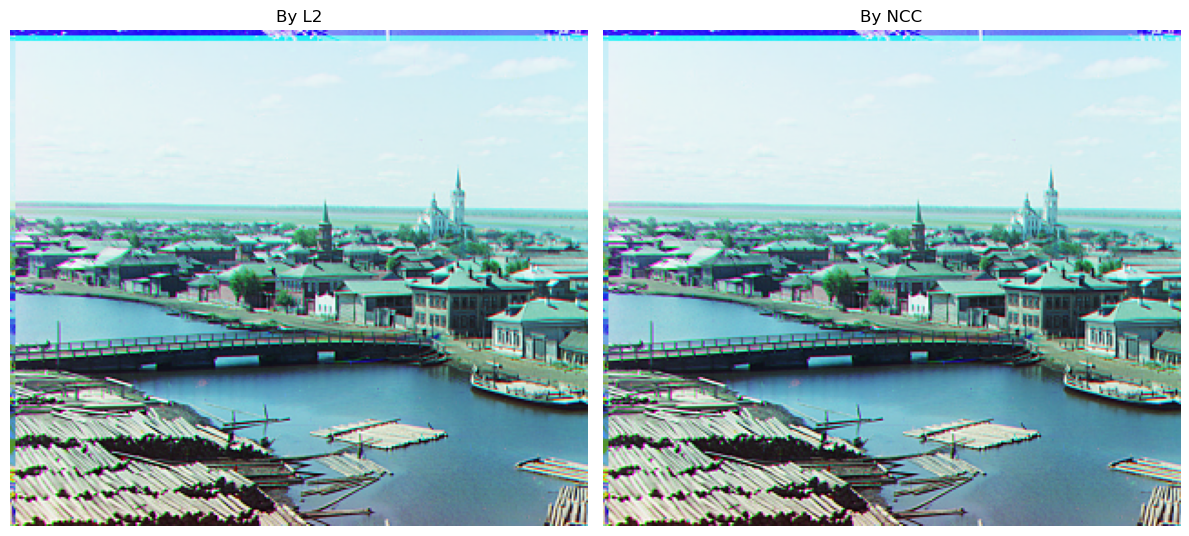

Saved: results\tobolsk.jpg


In [49]:
import matplotlib.pyplot as plt

combined_img, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(color_img_l2)
axes[0].set_title('By L2')
axes[0].axis('off')

axes[1].imshow(color_img_ncc)
axes[1].set_title('By NCC')
axes[1].axis('off')

plt.tight_layout()

output_dir = Path("results")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / f"{img_path.stem}.jpg"

combined_img.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_path)